In [13]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

In [14]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
full_dataloader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [15]:
def get_gradient_vector(model, dataloader, num_batches=1):
    """Helper to extract the flattened gradient vector from a model."""
    model.zero_grad()
    device = next(model.parameters()).device
    
    # Accumulate gradients over the specified number of batches
    for i, (X, y) in enumerate(dataloader):
        if i >= num_batches: break
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        loss.backward()
        
    # Flatten all gradients into a single 1D vector
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1))
    return torch.cat(grads)

In [16]:
import torch.optim as optim

# 1. Set up the SGD optimizer
# Use a "hot" temperature to ensure you land in a wide, flat valley
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print("Phase 1: Training the model to reach the local minimum...")

# 2. Train the model using your imported function
# (If your train_model returns a trained model, use it like this)
# Assuming 200 epochs is enough for this dataset to converge
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim, 
    lr=learning_rate, 
    batch_size=64, 
    epochs=200
)

# If your train_model modifies the model in-place, just call it.
# Now 'model' (or 'trained_model') is sitting at the bottom of the flat valley!
print("Training complete. The model is now in the diffusion phase.")

Phase 1: Training the model to reach the local minimum...
Epoch [100/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Epoch [200/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Training complete. The model is now in the diffusion phase.


In [17]:
print("Calculating Full-Batch True Gradient...")
true_grad = get_gradient_vector(trained_model, full_dataloader, num_batches=1)

print("Sampling Mini-Batch Gradients...")
num_samples = 500
noise_samples = []

# We will track the noise of a single, randomly chosen parameter (e.g., index 420)
# tracking the whole 14,218-dim vector 500 times takes too much memory!
param_index_to_track = 100 

for i in range(num_samples):
    # Get the gradient for just ONE mini-batch
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # V_k = (Mini-batch Grad) - (True Grad)
    # Note: In the thesis you defined V_k as True - Mini. Either way works, it's centered at 0!
    noise_vector = mini_grad - true_grad 
    
    # Store the noise for our specific parameter
    noise_samples.append(noise_vector[param_index_to_track].item())

noise_samples = np.array(noise_samples)
print("Noise sampling complete!")

Calculating Full-Batch True Gradient...
Sampling Mini-Batch Gradients...
Noise sampling complete!


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Assuming `noise_samples` has shape (num_samples, num_parameters)
# We isolate a parameter or project onto the top Hessian eigenvector (even better!)
projected_noise = noise_samples[:, 420] 

# --- 1. Fit Alpha-Stable Distribution (The Paper's Main Metric) ---
# alpha, beta, loc, scale
alpha, beta, _, _ = stats.levy_stable.fit(projected_noise)
print(f"Estimated Tail Index (Alpha): {alpha:.4f}") 
# If alpha is close to 2.0, it's strictly Gaussian!

# --- 2. Quantitative Normality Test ---
# Shapiro-Wilk test evaluates if the distribution deviates significantly from Gaussian
stat, p_value = stats.shapiro(projected_noise)
print(f"Shapiro-Wilk Normality Test: p-value = {p_value:.5f}")

# --- 3. Generate a Quantile-Quantile (Q-Q) Plot ---
# A Q-Q plot is vastly superior to a histogram because it isolates tail behavior
plt.figure(figsize=(6, 6))
stats.probplot(projected_noise, dist="norm", plot=plt)
plt.title(f"Q-Q Plot (Batch Size B={B}) \n Alpha={alpha:.2f}, p-val={p_value:.4f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f"Noise_Normality_B{B}.png", dpi=300)
plt.show()

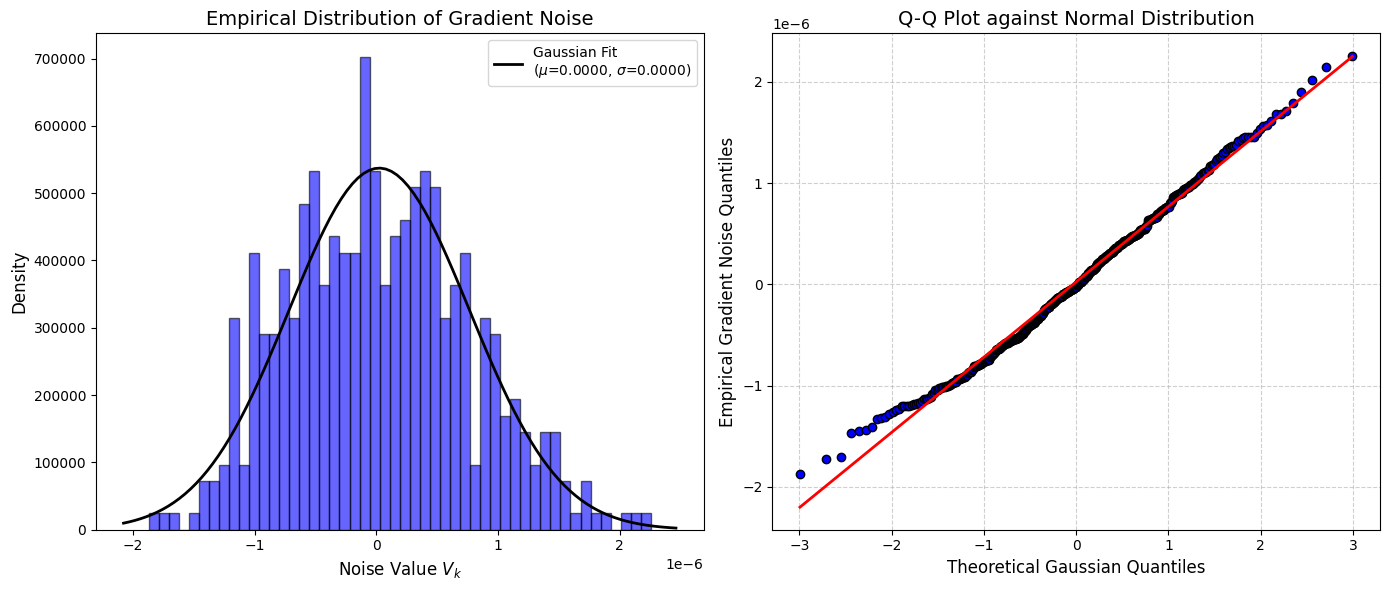

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Histogram with a Gaussian Fit
counts, bins, _ = ax1.hist(noise_samples, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
mu, std = stats.norm.fit(noise_samples)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax1.plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit\n($\mu$={mu:.4f}, $\sigma$={std:.4f})')

ax1.set_title("Empirical Distribution of Gradient Noise", fontsize=14)
ax1.set_xlabel("Noise Value $V_k$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.legend()

# Plot 2: The Q-Q Plot (The definitive proof)
stats.probplot(noise_samples, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[1].set_color('red') # The theoretical Gaussian line
ax2.get_lines()[1].set_linewidth(2)

ax2.set_title("Q-Q Plot against Normal Distribution", fontsize=14)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Gradient_Noise_Gaussianity_Test.png", dpi=300)
plt.show()

Sampling Mini-Batch Gradients for ALL weights...
Normalizing variances across all dimensions...
Plotting the Universal Q-Q Plot...


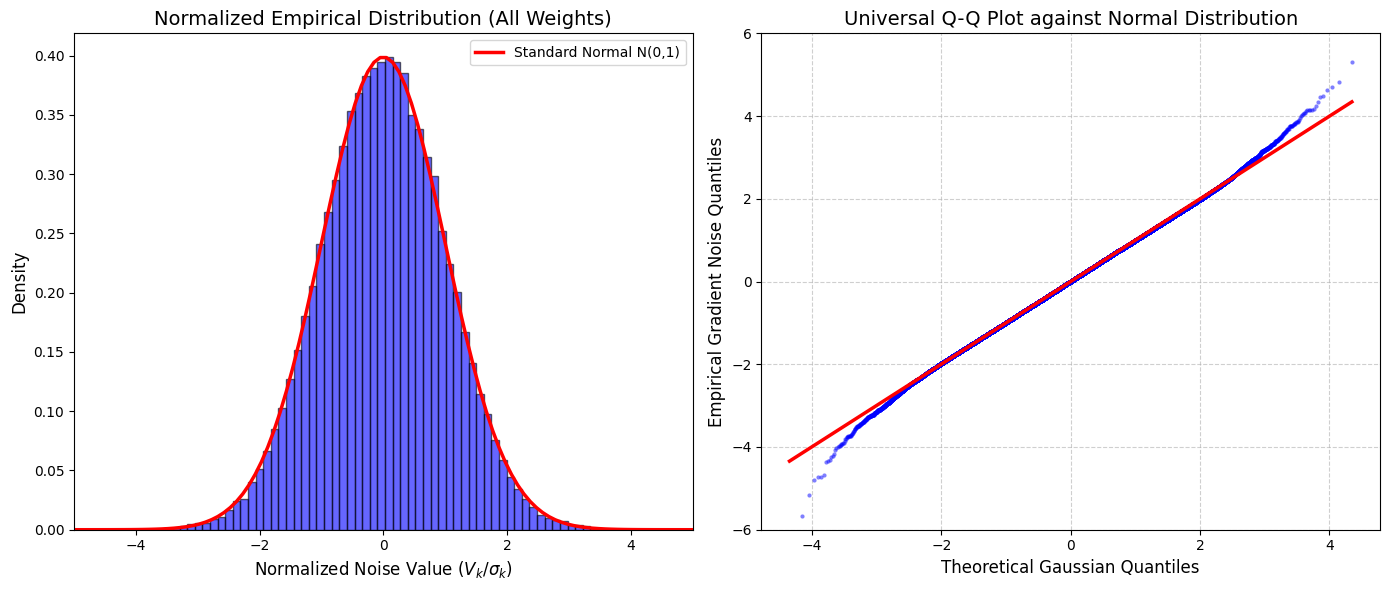

In [19]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ... (Assume true_grad and dataloaders are defined as before) ...

print("Sampling Mini-Batch Gradients for ALL weights...")
num_samples = 500
all_noise_samples = []

for i in range(num_samples):
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # Calculate noise for the entire 14,218-dimensional vector
    # Ensure gradients are detached and moved to CPU numpy arrays
    noise_vector = (mini_grad - true_grad).detach().cpu().numpy()
    all_noise_samples.append(noise_vector)

# Convert to a 2D numpy array of shape (500, 14218)
all_noise_samples = np.array(all_noise_samples)

print("Normalizing variances across all dimensions...")
# Calculate the standard deviation of noise for EACH individual parameter across the 500 steps
stds = np.std(all_noise_samples, axis=0)

# Safety check: avoid division by zero for parameters that might have 0 variance
stds[stds == 0] = 1.0

# Normalize each parameter's noise by its own standard deviation
# This forces every parameter to have a variance of 1.0, allowing us to safely pool them!
normalized_noise = all_noise_samples / stds

# Flatten the entire (500, 14218) matrix into a single 7.1 million-item 1D array
pooled_normalized_noise = normalized_noise.flatten()

print("Plotting the Universal Q-Q Plot...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Histogram (using a subset for faster plotting if 7M points is too slow)
plot_subset = np.random.choice(pooled_normalized_noise, size=100000, replace=False)
ax1.hist(plot_subset, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, 0, 1) # We compare to N(0,1) because we normalized it!
ax1.plot(x, p, 'r', linewidth=2.5, label='Standard Normal N(0,1)')

ax1.set_title("Pooled Normalized Noise (All Weights, B=64)\n[aggregate of ~14k dims — see note below]", fontsize=13)
ax1.set_xlabel("Normalized Noise Value $(V_k / \sigma_k)$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.set_xlim(-5, 5)
ax1.legend()

# Plot 2: Q-Q Plot
stats.probplot(plot_subset, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('none')
ax2.get_lines()[0].set_markersize(3)
ax2.get_lines()[0].set_alpha(0.5)
ax2.get_lines()[1].set_color('red') 
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title("Universal Q-Q Plot — Pooled Aggregate (B=64)\n[heavy-tail deviation visible at extremes]", fontsize=13)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig("Universal_Gradient_Noise_Gaussianity.png", dpi=300)
plt.show()


### Why larger batch sizes produce more Gaussian gradient noise — the CLT argument

The mini-batch gradient for parameter $i$ is the **average** of $B$ independent per-sample gradients:

$$\bar{g}_B^{(i)} = \frac{1}{B} \sum_{j=1}^{B} g_j^{(i)}$$

The gradient noise is the deviation of this average from the true (full-batch) mean $\mu^{(i)}$:

$$V_B^{(i)} = \bar{g}_B^{(i)} - \mu^{(i)} = \frac{1}{B} \sum_{j=1}^{B} \bigl(g_j^{(i)} - \mu^{(i)}\bigr)$$

This is exactly the setting of the **Central Limit Theorem**: a sum of $B$ i.i.d. zero-mean random variables, divided by $B$.  
The CLT guarantees that as $B$ grows, $V_B^{(i)}$ converges in distribution to a Gaussian — **regardless of how heavy-tailed the individual per-sample contributions** $g_j^{(i)} - \mu^{(i)}$ **are**:

$$\sqrt{B} \cdot V_B^{(i)} \xrightarrow{d} \mathcal{N}(0,\, \sigma_i^2) \quad \text{as } B \to \infty$$

| Batch size $B$ | # terms averaged | Tail behaviour |
|---|---|---|
| Small (e.g. 16) | Few — heavy tails survive | Non-Gaussian per dimension |
| Large (e.g. 1024) | Many — tails cancel out | Approximately Gaussian per dimension |

**Intuition:** at $B = 16$ you are averaging only 16 per-sample gradients. If any single sample has an unusually large gradient (a heavy-tailed event), it shifts the mini-batch average significantly. At $B = 1024$ you average 1024 samples; extreme values are diluted by the remaining 1023 terms and the distribution tightens toward a bell curve.

**This is the core result of Wu et al. (2021):** the gradient noise transitions from heavy-tailed to Gaussian as $B$ increases, and the Shapiro-Wilk percentage directly tracks how far along that convergence each batch size is.

---

*Note on the pooled plot above:* normalising by $\sigma_k$ and pooling all ~14 000 dimensions adds a **second** averaging step (across dimensions), which makes even the $B = 64$ aggregate look near-Gaussian. That is why the per-dimension Shapiro-Wilk test (cell below) is more sensitive — it bypasses this pooling effect.


--- Wu et al. (2021) Methodology: Percentage of Gaussianity ---
FAST_MODE=False | samples/B=500 | params=1000
Reusing cached noise_dict.
[Shapiro] B=  16 | % Gaussian: 13.5%  (0.07s)
[Shapiro] B=  64 | % Gaussian: 34.3%  (0.06s)
[Shapiro] B= 256 | % Gaussian: 75.2%  (0.06s)
[Shapiro] B=1024 | % Gaussian: 90.4%  (0.07s)


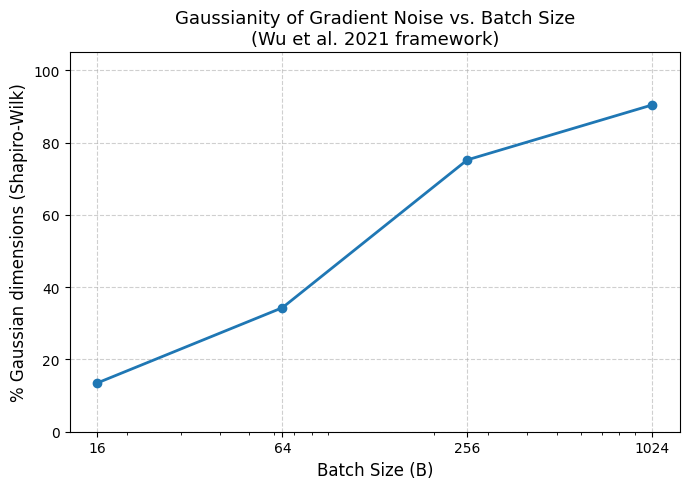

In [43]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import time

# --- Fast-mode settings ---
FAST_MODE = False
batch_sizes_to_test = [16, 64, 256] if FAST_MODE else [16, 64, 256, 1024]
num_samples_per_B   = 120           if FAST_MODE else 500
max_params_to_test  = 200           if FAST_MODE else 1000
p_value_threshold   = 0.05
rng = np.random.default_rng(42)

print("--- Wu et al. (2021) Methodology: Percentage of Gaussianity ---")
print(f"FAST_MODE={FAST_MODE} | samples/B={num_samples_per_B} | params={max_params_to_test}")

# ── Build noise_dict if not already in memory ─────────────────────────────────
if 'noise_dict' not in globals() or not isinstance(noise_dict, dict):
    print("\nBuilding noise_dict from mini-batch gradients...")
    noise_dict = {}
    t0 = time.perf_counter()
    true_grad = get_gradient_vector(trained_model, full_dataloader, num_batches=1).detach().cpu().numpy()

    for B in batch_sizes_to_test:
        t1 = time.perf_counter()
        mini_loader = DataLoader(dataset, batch_size=B, shuffle=True)
        loader_iter = iter(mini_loader)
        collected = []

        while len(collected) < num_samples_per_B:
            try:
                X, y = next(loader_iter)
            except StopIteration:
                loader_iter = iter(mini_loader)
                X, y = next(loader_iter)

            if len(X) != B:
                continue

            temp_loader = DataLoader(TensorDataset(X, y), batch_size=B, shuffle=False)
            mini_grad = get_gradient_vector(trained_model, temp_loader, num_batches=1).detach().cpu().numpy()
            collected.append(mini_grad - true_grad)

        noise_dict[B] = np.array(collected)
        print(f"  [Sampling] B={B:4d} -> shape {noise_dict[B].shape}  ({time.perf_counter()-t1:.1f}s)")

    print(f"noise_dict built in {time.perf_counter()-t0:.1f}s total.")
else:
    print("Reusing cached noise_dict.")

# ── Shapiro-Wilk Gaussianity sweep ───────────────────────────────────────────
gaussianity_percentages = []

for B in batch_sizes_to_test:
    t1 = time.perf_counter()
    noise_matrix = noise_dict[B]
    _, M = noise_matrix.shape

    params_to_test = min(M, max_params_to_test)
    indices = rng.choice(M, size=params_to_test, replace=False)

    gaussian_count = 0
    for idx in indices:
        _, p_value = stats.shapiro(noise_matrix[:, idx])
        if p_value > p_value_threshold:
            gaussian_count += 1

    percentage = gaussian_count / params_to_test * 100
    gaussianity_percentages.append(percentage)
    print(f"[Shapiro] B={B:4d} | % Gaussian: {percentage:.1f}%  ({time.perf_counter()-t1:.2f}s)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(batch_sizes_to_test, gaussianity_percentages, marker='o', color='tab:blue', linewidth=2)
ax.set_xlabel('Batch Size (B)', fontsize=12)
ax.set_ylabel('% Gaussian dimensions (Shapiro-Wilk)', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(batch_sizes_to_test)
ax.set_xticklabels(batch_sizes_to_test)
ax.set_ylim(0, 105)
ax.set_title('Gaussianity of Gradient Noise vs. Batch Size\n(Wu et al. 2021 framework)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Gaussianity_vs_BatchSize.png", dpi=300)
plt.show()


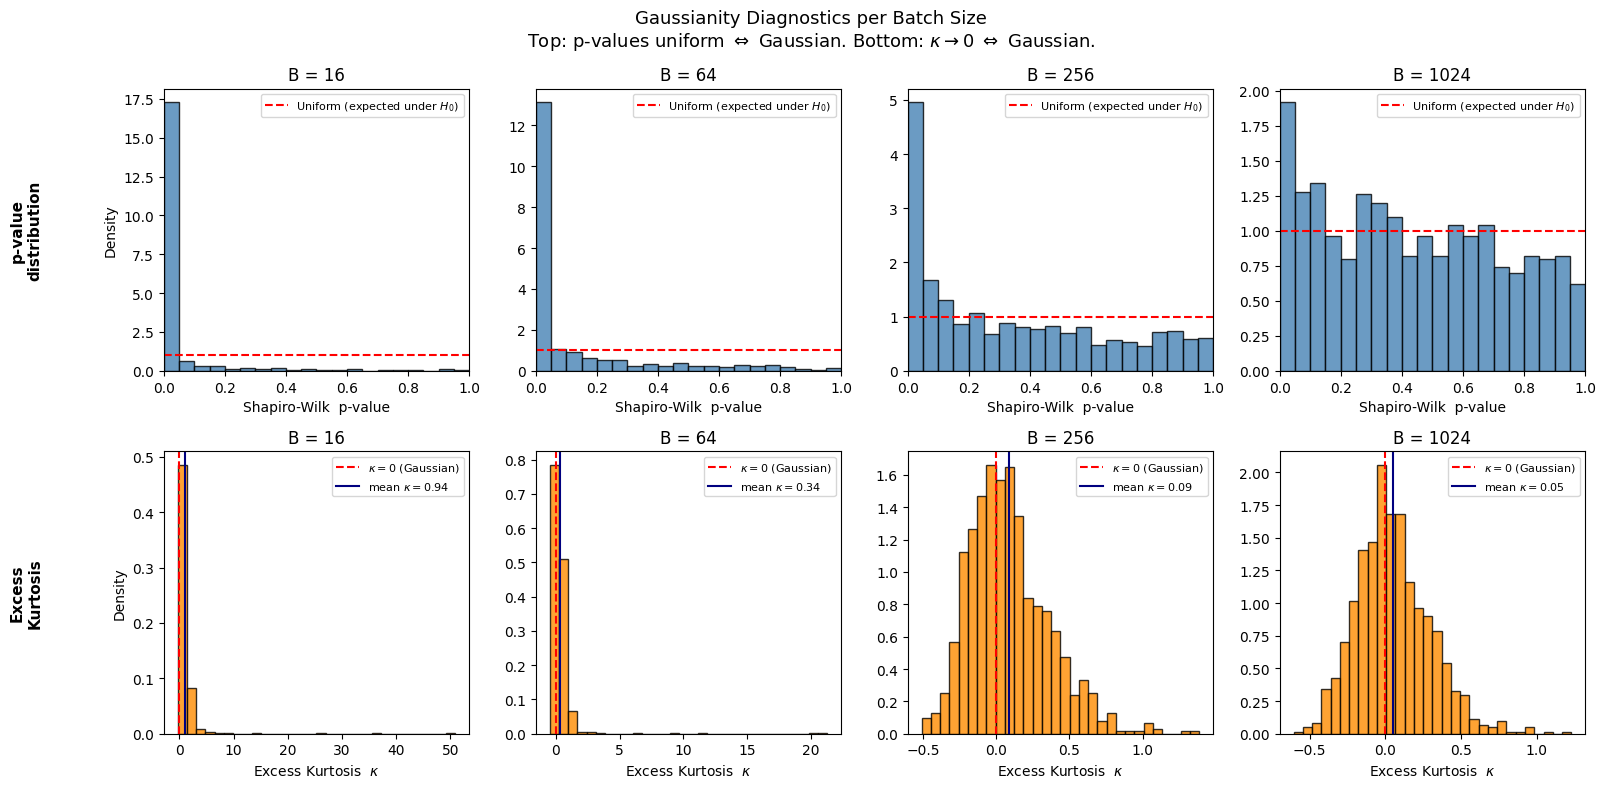

In [45]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ── Re-sample the same parameter indices (same seed → reproducible) ──────────
rng_diag = np.random.default_rng(42)

n_cols = len(batch_sizes_to_test)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for col, B in enumerate(batch_sizes_to_test):
    noise_matrix = noise_dict[B]
    _, M = noise_matrix.shape
    params_to_test = min(M, max_params_to_test)
    indices = rng_diag.choice(M, size=params_to_test, replace=False)

    p_values  = []
    kurtoses  = []
    for idx in indices:
        col_data = noise_matrix[:, idx]
        _, p = stats.shapiro(col_data)
        p_values.append(p)
        kurtoses.append(stats.kurtosis(col_data, fisher=True))  # excess kurtosis; 0 = Gaussian

    p_values = np.array(p_values)
    kurtoses = np.array(kurtoses)

    # ── Row 0: p-value histogram ──────────────────────────────────────────────
    ax0 = axes[0, col]
    ax0.hist(p_values, bins=20, range=(0, 1), color='steelblue',
             edgecolor='black', density=True, alpha=0.8)
    ax0.axhline(1.0, color='red', linestyle='--', linewidth=1.5,
                label='Uniform (expected under $H_0$)')
    ax0.set_title(f'B = {B}', fontsize=12)
    ax0.set_xlabel('Shapiro-Wilk  p-value', fontsize=10)
    ax0.set_xlim(0, 1)
    if col == 0:
        ax0.set_ylabel('Density', fontsize=10)
    ax0.legend(fontsize=8)

    # ── Row 1: excess kurtosis histogram ─────────────────────────────────────
    ax1 = axes[1, col]
    ax1.hist(kurtoses, bins=30, color='darkorange',
             edgecolor='black', density=True, alpha=0.8)
    ax1.axvline(0, color='red', linestyle='--', linewidth=1.5,
                label=r'$\kappa=0$ (Gaussian)')
    mean_k = np.mean(kurtoses)
    ax1.axvline(mean_k, color='navy', linestyle='-', linewidth=1.5,
                label=fr'mean $\kappa={mean_k:.2f}$')
    ax1.set_title(f'B = {B}', fontsize=12)
    ax1.set_xlabel('Excess Kurtosis  $\\kappa$', fontsize=10)
    if col == 0:
        ax1.set_ylabel('Density', fontsize=10)
    ax1.legend(fontsize=8)

# Row labels on the left
axes[0, 0].annotate('p-value\ndistribution', xy=(0, 0.5),
                    xycoords='axes fraction', xytext=(-0.45, 0.5),
                    textcoords='axes fraction', fontsize=11,
                    fontweight='bold', va='center', ha='center',
                    rotation=90)
axes[1, 0].annotate('Excess\nKurtosis', xy=(0, 0.5),
                    xycoords='axes fraction', xytext=(-0.45, 0.5),
                    textcoords='axes fraction', fontsize=11,
                    fontweight='bold', va='center', ha='center',
                    rotation=90)

fig.suptitle('Gaussianity Diagnostics per Batch Size\n'
             r'Top: p-values uniform $\Leftrightarrow$ Gaussian. '
             r'Bottom: $\kappa\to 0$ $\Leftrightarrow$ Gaussian.',
             fontsize=13)
plt.tight_layout()
plt.savefig("Gaussianity_Diagnostics.png", dpi=300)
plt.show()


In [87]:
import torch
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]  # Should be 100
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)

print("Phase 1: The Burn-in (Equilibration)...")
print("Training the model to reach the bottom of the minimum (theta*).")

# 3. Train the model to eliminate macroscopic drift
# We want it to thoroughly settle into the minimum, so 200-300 epochs is safe.
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim,
    lr=0.005, 
    batch_size=64, 
    epochs=250
)

# 4. Freeze the state
# We will use this trained_model for Phase 2 and 3
trained_model.eval()
print("Equilibration complete! The model is now resting at theta*.")

Phase 1: The Burn-in (Equilibration)...
Training the model to reach the bottom of the minimum (theta*).
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete! The model is now resting at theta*.


--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---
1. Sampling gradient noise...
2. Computing Top Principal Components of the Noise (Sigma)...
3. Computing Top Eigenvectors of the Hessian (H)...
4. Calculating Subspace Overlap...
Plotting the Alignment Heatmap...


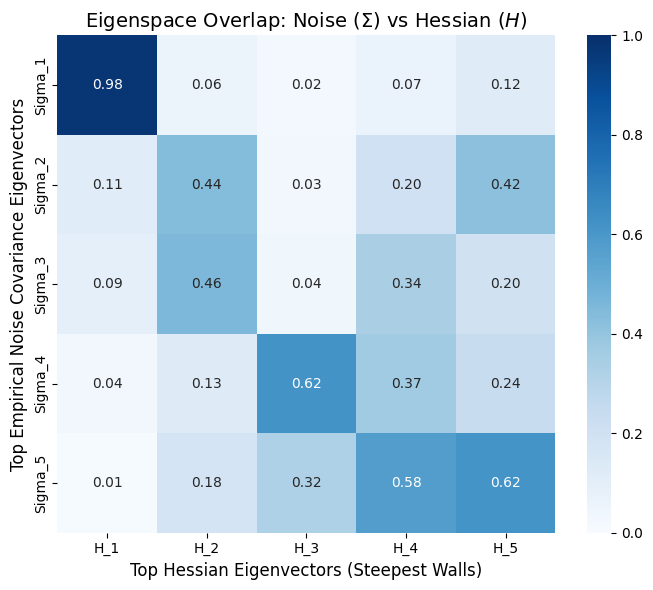

In [88]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader

# --- Settings ---
K = 5  # Number of top dimensions to compare
B = 64 # Mini-batch size for the noise
num_noise_samples = 500

print(f"--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---")
print("1. Sampling gradient noise...")

trained_model.eval()
criterion = torch.nn.CrossEntropyLoss()
device = next(trained_model.parameters()).device

# Function to get flattened gradient
def get_flat_gradient(X_batch, y_batch):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    trained_model.zero_grad()
    loss = criterion(trained_model(X_batch), y_batch)
    loss.backward()
    grads = [p.grad.contiguous().view(-1) for p in trained_model.parameters() if p.grad is not None]
    return torch.cat(grads)

# Get True Gradient (Full Batch)
# Note: For N=10000 you can load it in one batch, or accumulate it. 
# We'll assume full_dataloader can yield the whole dataset for the true gradient.
X_full, y_full = next(iter(full_dataloader))
true_grad = get_flat_gradient(X_full, y_full).detach().cpu().numpy()

# Sample mini-batch noise
mini_loader = DataLoader(dataset, batch_size=B, shuffle=True)
loader_iter = iter(mini_loader)

noise_matrix = []
for _ in range(num_noise_samples):
    try:
        X, y = next(loader_iter)
    except StopIteration:
        loader_iter = iter(mini_loader)
        X, y = next(loader_iter)
    
    if len(X) != B: continue
    
    mini_grad = get_flat_gradient(X, y).detach().cpu().numpy()
    noise_vector = mini_grad - true_grad
    noise_matrix.append(noise_vector)

noise_matrix = np.array(noise_matrix) # Shape: (500, M)
noise_mean = noise_matrix.mean(axis=0, keepdims=True)
centered_noise_matrix = noise_matrix - noise_mean

print("2. Computing Top Principal Components of the Noise (Sigma)...")
# SVD on centered samples extracts the eigendirections of the empirical covariance
U, S, Vh = np.linalg.svd(centered_noise_matrix, full_matrices=False)
noise_eigenvectors = Vh[:K] # Top K directions of the noise

print("3. Computing Top Eigenvectors of the Hessian (H)...")
# We use Hessian-Vector Products to avoid memory explosion

def compute_hvp(v_np):
    """Calculates H * v exactly without forming H."""
    v_tensor = torch.tensor(v_np, dtype=torch.float32).to(device)
    hvp_accum = torch.zeros_like(v_tensor)
    
    # We accumulate over batches to save GPU/CPU memory
    for X_b, y_b in DataLoader(dataset, batch_size=500):
        X_b, y_b = X_b.to(device), y_b.to(device)
        trained_model.zero_grad()
        loss = criterion(trained_model(X_b), y_b)
        
        # 1st derivative
        grads = torch.autograd.grad(loss, trained_model.parameters(), create_graph=True)
        flat_grad = torch.cat([g.contiguous().view(-1) for g in grads])
        
        # Dot product with vector v
        grad_v = torch.dot(flat_grad, v_tensor)
        
        # 2nd derivative (Hessian-vector product)
        hvp_grads = torch.autograd.grad(grad_v, trained_model.parameters())
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp_grads])
        
        hvp_accum += flat_hvp * len(X_b)
        
    return (hvp_accum / len(dataset)).detach().cpu().numpy()

# Define the matrix-free Linear Operator for SciPy
M = sum(p.numel() for p in trained_model.parameters())
H_op = LinearOperator((M, M), matvec=compute_hvp)

# scipy.sparse.linalg.eigsh finds the top K eigenvalues/eigenvectors using Lanczos iteration
evals, evecs = eigsh(H_op, k=K, which='LA')
# evecs are returned in ascending order, so we reverse them
hessian_eigenvectors = evecs[:, ::-1].T # Shape: (K, M)

print("4. Calculating Subspace Overlap...")
# We take the absolute dot product (cosine similarity) between the two sets of vectors
overlap_matrix = np.abs(np.dot(noise_eigenvectors, hessian_eigenvectors.T))

print("Plotting the Alignment Heatmap...")
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(overlap_matrix, annot=True, cmap='Blues', fmt=".2f", 
            xticklabels=[f"H_{i+1}" for i in range(K)], 
            yticklabels=[f"Sigma_{i+1}" for i in range(K)], 
            vmin=0, vmax=1, ax=ax)

ax.set_title("Eigenspace Overlap: Noise ($\Sigma$) vs Hessian ($H$)", fontsize=14)
ax.set_xlabel("Top Hessian Eigenvectors (Steepest Walls)", fontsize=12)
ax.set_ylabel("Top Empirical Noise Covariance Eigenvectors", fontsize=12)

plt.tight_layout()
plt.savefig("Hessian_Noise_Alignment.png", dpi=300)
plt.show()


Alignment evolution: Noise covariance Σ vs Hessian H eigenspace
  K = 5,  lr = 0.005,  B = 64,  total_steps = 30
  Alignment snapshots at steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
  Loss recorded every 500 steps
  Noise sampling seed fixed at 0 across all snapshots

  Model dimension M = 56842
  Random-subspace baseline = 8.80e-05

  Step      0  loss = 3.3469  avg cos²θ = 0.17177  (4.7s)
  Step      1  loss = 1.7894  avg cos²θ = 0.24873  (3.5s)
  Step      2  loss = 1.0453  avg cos²θ = 0.41355  (5.2s)
  Step      3  loss = 0.5819  avg cos²θ = 0.53545  (4.6s)
  Step      4  loss = 0.3938  avg cos²θ = 0.68983  (4.7s)
  Step      5  loss = 0.2499  avg cos²θ = 0.73300  (3.4s)
  Step      6  loss = 0.1944  avg cos²θ = 0.90355  (3.9s)
  Step      7  loss = 0.1545  avg cos²θ = 0.81771  (3.4s)
  Step      8  loss = 0.1287  avg cos²θ = 0.77854  (3.3s)
  Step      9  loss = 0.1098  avg cos²θ = 0.71913  (3.7s)
  Step    

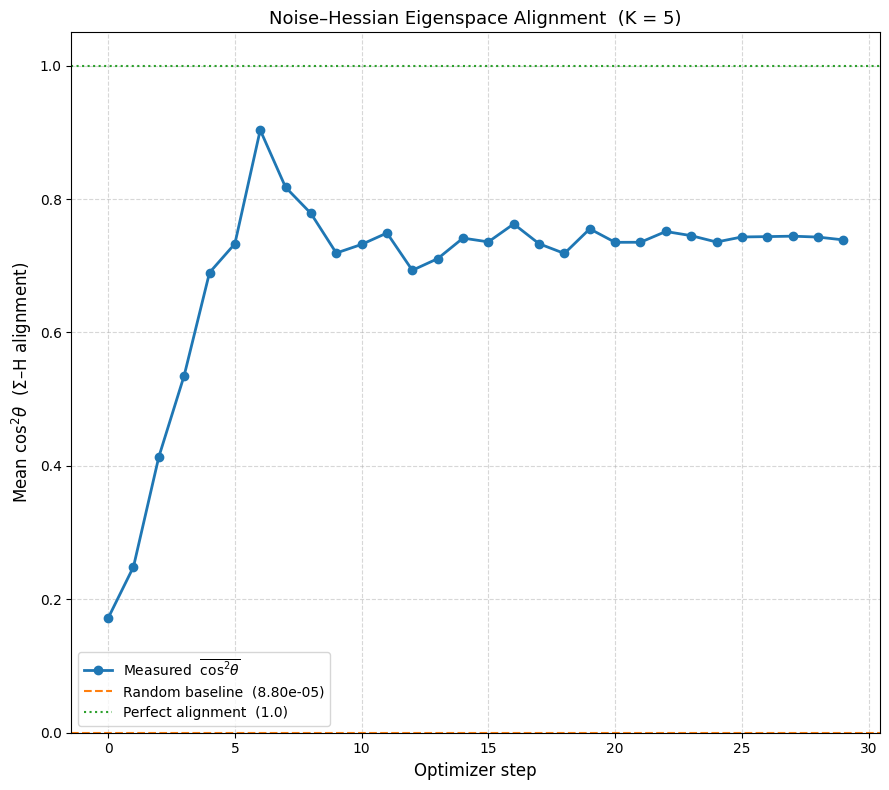

In [106]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import FlatMLP

# ── Settings ───────────────────────────────────────────────────────────────────
K_align        = 5       # subspace dimension (same as heatmap)
B_noise        = 64      # batch size for noise sampling
num_noise      = 150     # noise samples per snapshot
lr_train       = 0.005
B_train        = 64
total_steps    = 30      # optimizer steps (consistent with sweep cells)
steps_per_loss = 500     # full-batch loss evaluation interval
SEED           = 42
NOISE_SEED     = 0       # fixed seed for mini-batch draws in every snapshot
                         # → same batches used at every snapshot, removing
                         #   sampling variance from the alignment signal

# Alignment snapshots: dense early, coarser later (logarithmic-ish spacing)
snapshot_steps = sorted(set(range(0, 30, 1)))
snapshot_set   = set(snapshot_steps)

print(f"Alignment evolution: Noise covariance Σ vs Hessian H eigenspace")
print(f"  K = {K_align},  lr = {lr_train},  B = {B_train},  total_steps = {total_steps}")
print(f"  Alignment snapshots at steps: {snapshot_steps}")
print(f"  Loss recorded every {steps_per_loss} steps")
print(f"  Noise sampling seed fixed at {NOISE_SEED} across all snapshots")

# ── Helper: top-K noise covariance eigenvectors ────────────────────────────────
def get_noise_eigenvectors(model, dataset, B, num_samples, K, device, seed=0):
    """
    SVD on centered noise samples → top-K directions of Σ.
    `seed` pins the DataLoader shuffle so the same mini-batches are drawn
    at every snapshot, removing sampling randomness from the alignment signal.
    """
    crit = torch.nn.CrossEntropyLoss()
    X_f, y_f = dataset.tensors[0].to(device), dataset.tensors[1].to(device)
    model.zero_grad()
    crit(model(X_f), y_f).backward()
    true_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                        if p.grad is not None]).detach().cpu().numpy()

    g_noise = torch.Generator()
    g_noise.manual_seed(seed)
    loader = DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise)
    it = iter(loader)
    samples = []
    while len(samples) < num_samples:
        try:
            Xb, yb = next(it)
        except StopIteration:
            # Re-seed so we cycle through the same permutation order again
            g_noise.manual_seed(seed)
            it = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise))
            Xb, yb = next(it)
        if len(Xb) != B:
            continue
        model.zero_grad()
        Xb, yb = Xb.to(device), yb.to(device)
        crit(model(Xb), yb).backward()
        mini_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                            if p.grad is not None]).detach().cpu().numpy()
        samples.append(mini_g - true_g)

    noise_mat = np.array(samples)
    noise_mat -= noise_mat.mean(axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(noise_mat, full_matrices=False)
    return Vh[:K]   # (K, M)

# ── Helper: top-K Hessian eigenvectors ────────────────────────────────────────
def get_hessian_eigenvectors(model, dataset, K, device):
    crit = torch.nn.CrossEntropyLoss()
    M_dim = sum(p.numel() for p in model.parameters())

    def hvp(v_np):
        v_t = torch.tensor(v_np, dtype=torch.float32, device=device)
        accum = torch.zeros_like(v_t)
        for Xb, yb in DataLoader(dataset, batch_size=512, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            model.zero_grad()
            loss = crit(model(Xb), yb)
            grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
            gv = torch.dot(torch.cat([g.contiguous().view(-1) for g in grads]), v_t)
            hg = torch.autograd.grad(gv, model.parameters())
            accum += torch.cat([g.contiguous().view(-1) for g in hg]) * len(Xb)
        return (accum / len(dataset)).detach().cpu().numpy()

    H_op = LinearOperator((M_dim, M_dim), matvec=hvp)
    _, evecs_snap = eigsh(H_op, k=K, which='LA', tol=1e-3)
    return evecs_snap[:, ::-1].T   # (K, M)

# ── Helper: average cos²(θ) between two K-dim subspaces ───────────────────────
def mean_cos2_theta(Q_a, Q_b):
    G  = Q_a @ Q_b.T
    sv = np.linalg.svd(G, compute_uv=False)
    return float(np.mean(sv ** 2))

# ── Full-batch loss evaluation ─────────────────────────────────────────────────
def full_batch_loss(model, dataset, device, batch_size=512):
    crit = torch.nn.CrossEntropyLoss()
    total_loss, total_n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for Xb, yb in DataLoader(dataset, batch_size=batch_size, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            total_loss += crit(model(Xb), yb).item() * len(Xb)
            total_n    += len(Xb)
    model.train()
    return total_loss / total_n

# ── Training loop (step-based) ─────────────────────────────────────────────────
torch.manual_seed(SEED)
track_model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
opt_track   = torch.optim.SGD(track_model.parameters(), lr=lr_train)
crit_track  = torch.nn.CrossEntropyLoss()
device_t    = next(track_model.parameters()).device

train_loader  = DataLoader(dataset, batch_size=B_train, shuffle=True,
                           generator=torch.Generator().manual_seed(SEED))
alignment_history = []   # (step, avg_cos2)
loss_history      = []   # (step, loss)

M_dim           = sum(p.numel() for p in track_model.parameters())
random_baseline  = K_align / M_dim

print(f"\n  Model dimension M = {M_dim}")
print(f"  Random-subspace baseline = {random_baseline:.2e}\n")

global_step = 0
done        = False
t_start     = time.perf_counter()

# ── Measure at step 0 before any training ──
fl = full_batch_loss(track_model, dataset, device_t)
loss_history.append((0, fl))
track_model.eval()
t0      = time.perf_counter()
Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise, num_noise, K_align,
                                 device_t, seed=NOISE_SEED)
Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
alignment_history.append((0, avg_c2))
print(f"  Step {0:6d}  loss = {fl:.4f}  avg cos²θ = {avg_c2:.5f}  ({time.perf_counter()-t0:.1f}s)")
track_model.train()

while not done:
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device_t), yb.to(device_t)
        opt_track.zero_grad()
        crit_track(track_model(Xb), yb).backward()
        opt_track.step()
        global_step += 1

        # Record loss at fixed interval
        if global_step % steps_per_loss == 0:
            fl = full_batch_loss(track_model, dataset, device_t)
            loss_history.append((global_step, fl))

        # Record alignment at snapshot steps
        if global_step in snapshot_set:
            fl_snap = full_batch_loss(track_model, dataset, device_t)
            if not loss_history or loss_history[-1][0] != global_step:
                loss_history.append((global_step, fl_snap))
            track_model.eval()
            t0      = time.perf_counter()
            Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise,
                                             num_noise, K_align, device_t,
                                             seed=NOISE_SEED)
            Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
            avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
            alignment_history.append((global_step, avg_c2))
            print(f"  Step {global_step:6d}  loss = {fl_snap:.4f}  avg cos²θ = {avg_c2:.5f}"
                  f"  ({time.perf_counter()-t0:.1f}s)")
            track_model.train()

        if global_step >= total_steps:
            done = True
            break

print(f"\nTotal time: {time.perf_counter()-t_start:.1f}s")

# ── Sort loss history by step (in case snapshot + interval overlap) ────────────
loss_history.sort(key=lambda x: x[0])

# ── Plot ───────────────────────────────────────────────────────────────────────
steps_arr   = [s for s, _ in alignment_history]
cos2_arr    = [c for _, c in alignment_history]
loss_steps  = [s for s, _ in loss_history]
loss_vals   = [l for _, l in loss_history]

fig, ax_align = plt.subplots(1, 1, figsize=(9, 8), sharex=True)


# — Bottom panel: alignment —
ax_align.plot(steps_arr, cos2_arr, marker='o', color='tab:blue', linewidth=2,
              markersize=6, label=r'Measured  $\overline{\cos^2\!\theta}$')
ax_align.axhline(random_baseline, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Random baseline  ({random_baseline:.2e})')
ax_align.axhline(1.0, color='tab:green', linestyle=':', linewidth=1.5,
                 label='Perfect alignment  (1.0)')
ax_align.set_xlabel('Optimizer step', fontsize=12)
ax_align.set_ylabel(r'Mean $\cos^2\!\theta$  (Σ–H alignment)', fontsize=12)
ax_align.set_title(f'Noise–Hessian Eigenspace Alignment  (K = {K_align})', fontsize=13)
ax_align.set_ylim(bottom=0)
ax_align.legend(fontsize=10)
ax_align.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Alignment_vs_Step.png", dpi=300)
plt.show()
